# **Introducción a ML: Análisis del Dataset de Cereales**

Fernanda Lizeth Zambrano Gudiño

Exploración inicial de un dataset de cereales para identificar variables, proponer una variable objetivo y plantear posibles problemas de Machine Learning (supervisado y no supervisado)


## Parte 1 – Reflexión conceptual

1. ¿Qué entiendes por Machine Learning y cómo se diferencia de la programación tradicional?  

R= En la programación tradicional, el programador le dice explícitamente a la computadora qué reglas seguir para llegar a un resultado. En Machine Learning, en cambio, el programador le da datos y resultados de ejemplo, y es la computadora la que identifica los patrones y aprende las reglas por sí misma, sin que se le programen paso a paso.


2. Da un ejemplo en tu área de interés donde se podría aplicar ML.  

R= Lo podría aplicar en el ámbito de salud para identificar patrones en ciertas enfermedades y así poder prevenirlas por ejemplo predecir el riesgo de que un paciente desarrolle diabetes tipo 2 usando datos especificos


3. ¿Cuál crees que es el papel de la estadística y probabilidad en ML?  

R= Asumo que ayuda en la parte de predecir al sacar probabilidades de que algo ocurra y auda a entender los datos



---

## Exploración de datos


In [1]:
# Importar librerías básicas
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/IvTole/MachineLearning_InferenciaBayesiana_CUGDL/refs/heads/main/data/cereal/cereal.csv"
df = pd.read_csv(url)

df.head() # primeras filas

,name,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
0,100% Bran,N,C,70,4,1,130,10.0,5.0,6,280,25,3,1.0,0.33,68.402973
1,100% Natural Bran,Q,C,120,3,5,15,2.0,8.0,8,135,0,3,1.0,1.00,33.983679
2,All-Bran,K,C,70,4,1,260,9.0,7.0,5,320,25,3,1.0,0.33,59.425505
3,All-Bran with Extra Fiber,K,C,50,4,0,140,14.0,8.0,0,330,25,3,1.0,0.50,93.704912
4,Almond Delight,R,C,110,2,2,200,1.0,14.0,8,-1,25,3,1.0,0.75,34.384843


## Parte 4

¿Que variables cualitativas/categóricas y cuantitativas tienes en el dataset?

R= El nombre del cereal, tipo y mfr

In [2]:
# Información general del dataset
# df.info()
df.info(url)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      77 non-null     object 
 1   mfr       77 non-null     object 
 2   type      77 non-null     object 
 3   calories  77 non-null     int64  
 4   protein   77 non-null     int64  
 5   fat       77 non-null     int64  
 6   sodium    77 non-null     int64  
 7   fiber     77 non-null     float64
 8   carbo     77 non-null     float64
 9   sugars    77 non-null     int64  
 10  potass    77 non-null     int64  
 11  vitamins  77 non-null     int64  
 12  shelf     77 non-null     int64  
 13  weight    77 non-null     float64
 14  cups      77 non-null     float64
 15  rating    77 non-null     float64
dtypes: float64(5), int64(8), object(3)
memory usage: 9.8+ KB


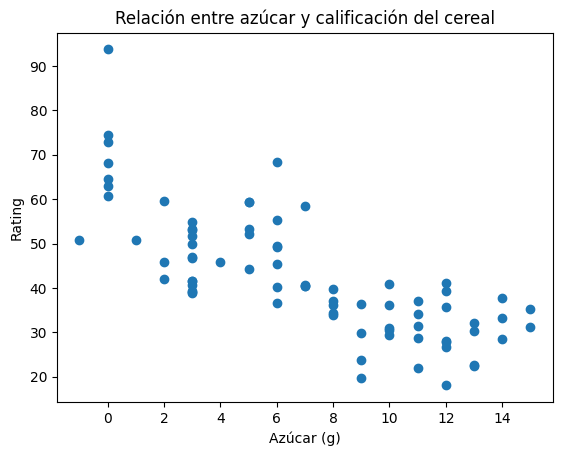

In [15]:
import matplotlib.pyplot as plt # Librería para hacer las gráficas

X_name = df['sugars'].to_frame() # Nos aseguramos que la matriz de características sea realmente una matriz (o un dataframe en este caso)
y_name = df['rating'] # Variable objetivo


plt.scatter(df['sugars'], df['rating']) #Dibuja un scatter plot
plt.xlabel('Azúcar (g)')
plt.ylabel('Rating')
plt.title('Relación entre azúcar y calificación del cereal')
plt.show()

Cada punto representa un cereal con su nivel de azucar en el eje X y su calificación en el eje Y. En la gráfica podemos ver que hay una relación negativa entre ambas variables, esto quiere decir que cuando el azúcar sube el rating baja. Tambien podemos observar que hay  dispersión por lo que  tienen una relación moderada ya que hay una tendencia clara pero lso puntos están bastante disperosos entre sí. Esto concluye que el azúcar si interfiere en rating pero de un cereal pero no es el único factor

In [5]:
# Ejemplo de separación de variables categóricas y numéricas

num_vars = df.select_dtypes(include=[np.number]).columns
cat_vars = df.select_dtypes(exclude=[np.number]).columns

print("Variables numéricas:", list(num_vars))
print("Variables categóricas:", list(cat_vars))

Variables numéricas: ['calories', 'protein', 'fat', 'sodium', 'fiber', 'carbo', 'sugars', 'potass', 'vitamins', 'shelf', 'weight', 'cups', 'rating']
Variables categóricas: ['name', 'mfr', 'type']


## Parte 5

¿Cuál variable propondrías como **target/objetivo** en un modelo de ML? ¿Por qué?

En base a esto, y con tus palabras, propón un ejemplo de problema supervisado / no supervisado que podría resolverse con estos datos.

Eligiría "rating" como variable objetivo ya que en base a las otras característuicas se podría predecir que cereal tendría mejores resultados.

No supervisado: seria agregar cereales y sus datos sin dar el rating para que el modelo vaya haciendo grupos para que encuentre patrones por si mismo

Supervisado:  darle al modelo las caracteristicas y el rating real de los cereales para que aprenda de esos datos y pueda predecir el rating de un cereal nuevo